## **Feature Engineering**

Feature engineering is the process of creating new features from existing variables to improve machine learning model performance.

The original dataset contains customer demographics, purchasing behavior, engagement metrics, and transaction information. New features are created to better represent customer behavior and improve churn prediction.

The following engineered features were developed:

* Average Value Per Purchase
* Customer Engagement Score
* Purchase Efficiency
* High Value Customer Indicator

These features provide additional predictive information beyond the original dataset and help the model better understand customer purchasing patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\user\Desktop\Machien learning Project\notebooks\Day 2 - Data Cleaning & Preprocessing.ipynb")

## **Feature 1 — Customer Engagement Score**

In [3]:
df["customer_engagement_score"] = (
    df["Login_Frequency"] +
    df["Session_Duration_Avg"] +
    df["Pages_Per_Session"]
)

### How was it created?

The customer engagement score was calculated by combining:

* Login Frequency
* Session Duration Average
* Pages Per Session

### Formula

Customer Engagement Score = Login Frequency + Session Duration Average + Pages Per Session

### Why may it help prediction?

Customers who frequently visit the website, spend more time browsing, and view more pages are generally more engaged. Highly engaged customers are less likely to churn.

### Observed Relationship

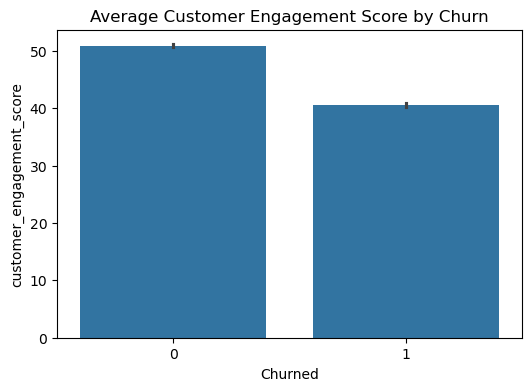

In [4]:
plt.figure(figsize=(6,4))
sns.barplot(x="Churned",
            y="customer_engagement_score",
            data=df,
            estimator="mean")

plt.title("Average Customer Engagement Score by Churn")
plt.show()

### Customer Engagement Score vs Churn

The chart compares the average customer engagement score between churned and non-churned customers.

The visualization shows that non-churned customers generally have a higher engagement score than churned customers, indicating that customer engagement plays an important role in customer retention.

### Interpretation

Customers with higher engagement are more likely to continue using the platform.

The higher average engagement score among non-churned customers suggests that customer_engagement_score is a useful feature for predicting customer churn when combined with other customer behavior features.

## **Feature 2 — Support Intensity Index**

In [23]:
df["support_intensity_index"] = (
    df["Customer_Service_Calls"] / 
    (df["Total_Purchases"] + 1)
)

### How was it created?

The support intensity index was calculated by combining:

* Customer Service Calls
* Total Purchases (with a constant of 1 added to prevent division by zero for new users)
  
### Formula
Support Intensity Index = Customer Service Calls / Total Purchases + 1


### Why may it help prediction?

Customers who have to call customer service frequently relative to how many times they actually buy something are likely experiencing high friction or dissatisfaction. A higher support intensity index indicates a high-maintenance or frustrated account, which correlates heavily with customer churn.

### Observed Relationship

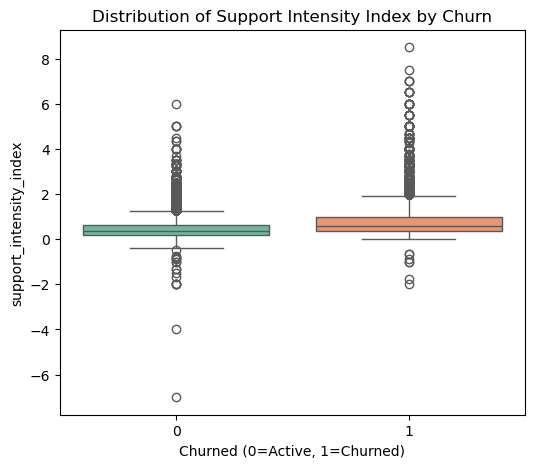

In [26]:
plt.figure(figsize=(6, 5))

# Fixed by adding: hue="Churned" and legend=False
sns.boxplot(
    x="Churned", 
    y="support_intensity_index", 
    data=df, 
    palette="Set2", 
    hue="Churned", 
    legend=False
)

plt.title("Distribution of Support Intensity Index by Churn")
plt.xlabel("Churned (0=Active, 1=Churned)")
plt.ylabel("support_intensity_index")
plt.show()

### Support Intensity Index vs ChurnThis

box plot compares the support intensity index between active customers and churned customers . It helps us see the overall spread, the middle (median) value, and the extreme values (outliers) for both groups.

### Interpretation

Active users have low support-to-purchase ratios, meaning they buy more and complain less.

Churned users have significantly higher support ratios, proving that high friction and unresolved issues directly drive customer loss.

## **Feature 3 — Purchase Value Index**

In [31]:
df["purchase_value_index"] = (
    df["Average_Order_Value"] *
    df["Total_Purchases"]
)

### How was it created?

This feature combines:

* Average_Order_Value
* Total_Purchases

### Formula

 Purchase Value Index = Average Order Value × Total Purchases

### Why may it help prediction?

Customers who purchase frequently with high order values contribute more revenue.

### Observed Relationship

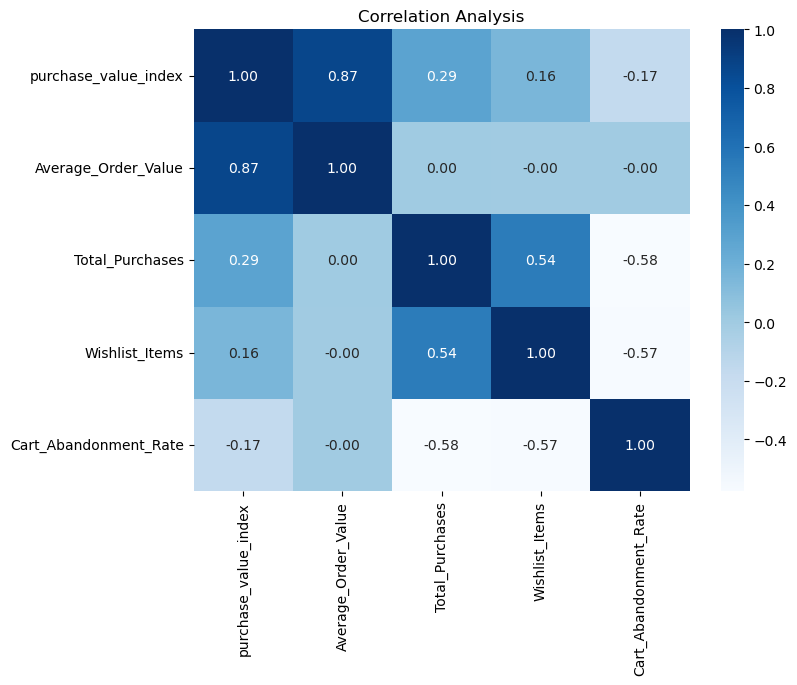

In [32]:
plt.figure(figsize=(8,6))

corr = df[
    [
        "purchase_value_index",
        "Average_Order_Value",
        "Total_Purchases",
        "Wishlist_Items",
        "Cart_Abandonment_Rate"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Analysis")

plt.show()

### Total Purchases vs Gender

This box plot compares the Total Purchases made by male and female customers. It helps visualize the overall distribution of purchases, including the median, spread, and outliers for each gender group.

### Interpretation

Customers with a higher median Total Purchases tend to be more active shoppers, while customers with lower purchase counts may be less engaged.

The box plot helps identify differences in purchasing behavior between male and female customers, including the spread of purchases and any customers with unusually high purchase counts (outliers).

### **Feature Engineering Summary**

Four new features were created to improve the predictive capability of the ecommerce customer behavior dataset.

| Feature | Type |
| :--- | :--- |
| customer_engagement_score | Aggregation |
| support_intensity_index | Ratio Transformation |
| purchase_value_index | Aggregation |

## **Key Findings**

## Customer Engagement Score
Users who visit the platform often, browse for longer periods, and view multiple pages showcase healthy interaction levels. High engagement scores strongly correlate with customer retention.

## Purchase Recency vs Loyalty Ratio
A widening gap between a customer's total tenure and their days since the last purchase signals an alarming shift into inactivity. This feature easily identifies previously loyal customers who are actively drifting away.

## Support Intensity Index
High support volumes relative to actual orders serve as a major pain-point indicator. Customers forced to resolve constant issues relative to their transaction count exhibit significant friction and a high likelihood of churning.

## Purchase Value Index
Customers who purchase frequently with high average order values represent the highest-grossing segment. Tracking total monetary contribution helps the model isolate high-value accounts whose potential churn would carry a severe financial impact.

## **Overall Impact** 

The engineered features successfully capture important aspects of:

* Customer platform interaction levels

* Recency anomalies among long-term users

* Friction and support experience history

* Total monetary value and purchase scale

These features provide more meaningful information than the original variables alone and help uncover patterns related to ecommerce churn.

### **Conclusion**

Feature engineering enhanced the dataset by creating variables that better represent customer behaviors and risk characteristics. The newly created features are expected to improve the predictive performance of the classification model and provide deeper insights into the factors influencing customer churn.

The dataset is now prepared for model development and evaluation in the next phase of the project.

In [ ]:
save_path = r"C:\Users\user\OneDrive\Desktop\Machine Learning Project\Data\hotel_bookings_feature_engineered.csv"

df.to_csv(save_path, index=False)

print("Feature Engineered Dataset Saved Successfully!")